# Model training and testing

In the following notebook we will work with the numpy data generated by the data_processing.ipynb notebook to train and test machine learning models.

### First model: ANN in keras

We must start by loading the data stored from the data processing stage, this means both the stars one hot encoding dictionary, as well as the numpy arrays containing the training and test spectrum data and label data.

In [75]:
# load the one hot encoding dictionary from the pre processing stage

import pickle

with open("stars_encoding.txt", "rb") as myFile:
    stars_encoding = pickle.load(myFile)

print(stars_encoding)

{'WDA': array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'WDZ': array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'WDB': array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'WDO': array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]), 'WD+MS': array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]), 'WD': array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]), 'sdX': array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]), 'WDH': array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]), 'WDELM': array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]), 'WDC': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]), 'CV': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]), 'WDQ': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])}


In [76]:
# now we will load the training and validation set matrices

import numpy as np

train_spectrum_matrix = np.load('training_spectrum_matrix.npy')
train_label_matrix = np.load('training_label_matrix.npy')

valid_spectrum_matrix = np.load('validation_spectrum_matrix.npy')
valid_label_matrix = np.load('validation_label_matrix.npy')

In [78]:
print(train_spectrum_matrix.shape, train_label_matrix.shape, valid_spectrum_matrix.shape, valid_label_matrix.shape)

(3366, 4200) (3366, 12) (1123, 4200) (1123, 12)


Now, we are still facing the problem of having to train an umbalanced set. There are many strategies which will have to be explored in order to solve this issue. For example:

<ul>
  <li>We could undersample the biggest dataset, oversample it, or a combination of both. There are also numerous algorithms to do so.</li>
  <li>We could take advantage of the fact that there are a number of different observations from the same object so as to perform data augmentation using those spectrums, instead of one per object.</li>
  <li>We could use class weights in the optimization process, as a parameter to the model.fit call.</li>
  <li>We could perform other data augmentation techniques, like looking for other similarly classified spectra elsewhere, building synthetic spectra, etc.</li>
</ul> 

For simplicity in this example, we'll simply undersample the majority class in the trainig set. Code is also available (commented) to try out the class wegiht parameter for model.fit

In [97]:
# try running pip install imblearn if this line doesn't work.
# Resampling the majority dataset in order to balance the set.

from imblearn.under_sampling import RandomUnderSampler
under_sampler = RandomUnderSampler(random_state=40, sampling_strategy='majority')
X_res, y_res = under_sampler.fit_resample(train_spectrum_matrix, train_label_matrix)

We can now see the distribution of the one hot encoded labels

In [98]:
from collections import Counter

newLabels = Counter()
for label in y_res:
    for idx, key in enumerate(label):
         newLabels[idx]+=key

print(newLabels)

Counter({4: 327, 9: 215, 2: 201, 8: 135, 5: 80, 6: 70, 10: 67, 1: 55, 7: 31, 3: 10, 0: 6, 11: 6})


### ANN training example

Now we can take our resample data (which resampled or in this case, undersampled the majority class) and train our ANN model. This particular ANN structure will have the same hidden layers and acxtivation functions found in Sharma et al, but other parameters may not be the same.

In [91]:
# Code to inpuit class weights parameter for model.fit

# First we'll define a class weight dictionary
# from sklearn.utils.class_weight import compute_class_weight

# y_integers = np.argmax(train_label_matrix, axis=1)
# class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_integers), y=y_integers)
# d_class_weights = dict(enumerate(class_weights))
# print(d_class_weights)

{0: 0.12932226832641772, 1: 5.1, 2: 1.3955223880597014, 3: 28.05, 4: 0.8577981651376146, 5: 3.50625, 6: 4.007142857142857, 7: 9.048387096774194, 8: 2.077777777777778, 9: 1.3046511627906976, 10: 4.186567164179104, 11: 46.75}


We now proceed to define our model, and other relevant parameters for training the ANN using keras. We will train our model using batch sizes of 32 samples (our ANN weights will be updated using batches or chunks of 32 samples) and for 100 epochs (we will go over our training set for a total of 100 times).

In [104]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD
#opt = SGD(lr=0.001)

model = Sequential([Dense(4200, input_dim = 4200, activation='relu', kernel_initializer='uniform'),
                    Dense(32, activation='relu', kernel_initializer='uniform'),
                    Dense(64, activation='relu', kernel_initializer='uniform'),
                    Dense(len(stars_encoding), activation='softmax', kernel_initializer='uniform')])

opt = keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
history = model.fit(X_res, y_res, batch_size=32, epochs=100 , validation_data=(valid_spectrum_matrix, valid_label_matrix))

Epoch 1/100
38/38 [==============================] - 4s 98ms/step - loss: 2.8771 - accuracy: 0.4073 - val_loss: 3.5392 - val_accuracy: 0.1817
Epoch 2/100
38/38 [==============================] - 3s 89ms/step - loss: 1.8647 - accuracy: 0.4863 - val_loss: 4.2417 - val_accuracy: 0.1977
Epoch 3/100
38/38 [==============================] - 3s 87ms/step - loss: 1.5337 - accuracy: 0.5611 - val_loss: 4.1725 - val_accuracy: 0.2164
Epoch 4/100
38/38 [==============================] - 3s 86ms/step - loss: 1.3653 - accuracy: 0.5919 - val_loss: 3.5471 - val_accuracy: 0.2146
Epoch 5/100
38/38 [==============================] - 3s 87ms/step - loss: 1.6910 - accuracy: 0.5960 - val_loss: 3.7772 - val_accuracy: 0.2324
Epoch 6/100
38/38 [==============================] - 3s 87ms/step - loss: 1.1718 - accuracy: 0.6517 - val_loss: 3.4115 - val_accuracy: 0.2342
Epoch 7/100
38/38 [==============================] - 3s 86ms/step - loss: 1.1415 - accuracy: 0.6367 - val_loss: 2.9950 - val_accuracy: 0.2155
Epoch 

Now that we have trained the model, we can see it's metrics

In [105]:
from sklearn.metrics import confusion_matrix

valid_sample_output = model.predict(valid_spectrum_matrix, batch_size=60)

19/19 [==============================] - 0s 16ms/step


In [106]:
predict_class = np.argmax(valid_sample_output, axis=1)
actual_class = np.argmax(valid_label_matrix, axis=1)
cf_matrix = confusion_matrix(actual_class, predict_class)

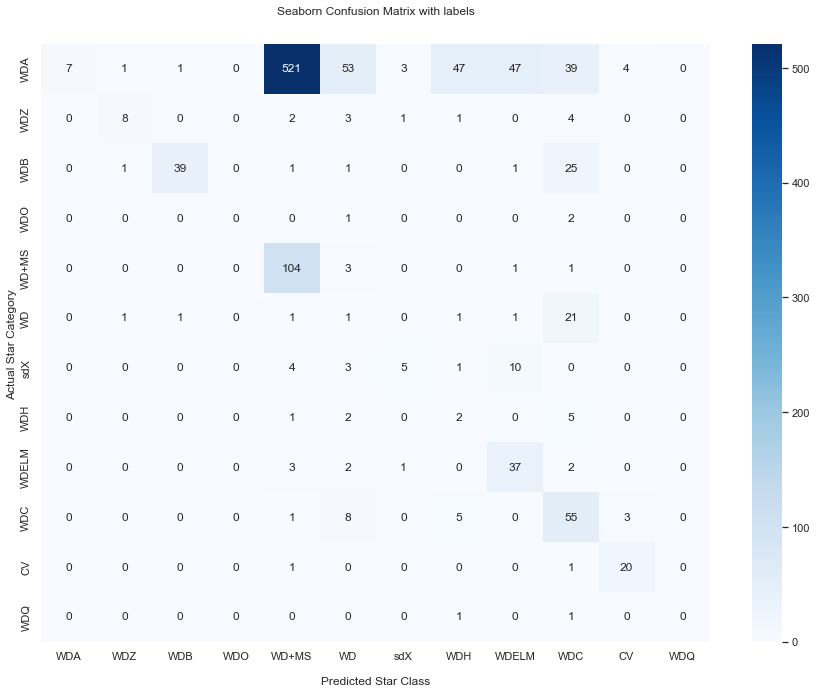

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

star_class = list(stars_encoding.keys())

sns.set(rc = {'figure.figsize':(15,11)})
ax = sns.heatmap(cf_matrix, annot=True, fmt='.3g', cmap='Blues')

ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Star Class')
ax.set_ylabel('Actual Star Category ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(star_class)
ax.yaxis.set_ticklabels(star_class)

## Display the visualization of the Confusion Matrix.
plt.show()

This confussion matrix shows that, using our undersampling scheme, the most problematic class turns out to be the WDA class! This may mean, for example, that we should explore a more inteligent undersampling algorithm (intead of random undersampling) so as to preserve the most information possible. Of course, we could also explore any other data augmentation scheme, as well as other models.

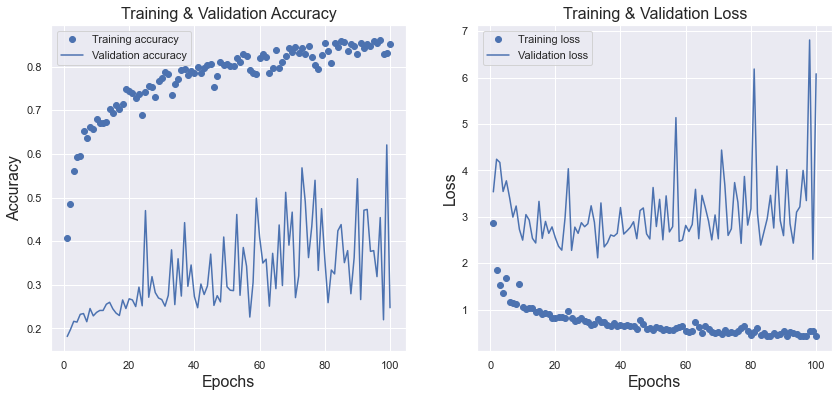

In [108]:
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']
 
epochs = range(1, len(loss_values) + 1)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
#
# Plot the model accuracy vs Epochs
#
ax[0].plot(epochs, accuracy, 'bo', label='Training accuracy')
ax[0].plot(epochs, val_accuracy, 'b', label='Validation accuracy')
ax[0].set_title('Training & Validation Accuracy', fontsize=16)
ax[0].set_xlabel('Epochs', fontsize=16)
ax[0].set_ylabel('Accuracy', fontsize=16)
ax[0].legend()
#
# Plot the loss vs Epochs
#
ax[1].plot(epochs, loss_values, 'bo', label='Training loss')
ax[1].plot(epochs, val_loss_values, 'b', label='Validation loss')
ax[1].set_title('Training & Validation Loss', fontsize=16)
ax[1].set_xlabel('Epochs', fontsize=16)
ax[1].set_ylabel('Loss', fontsize=16)
ax[1].legend()

Now, we can see the model is adjusting steadily to the training set, though the loss function has large oscilations. On the other hand, the loss function for the validation set steadily decreases, but the validation set accuracy presents large oscilations, so our model requires more work!
